In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/raw/AB_NYC_2019.csv')
print(df.shape)
print(df.head())

(48895, 16)
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1           

In [44]:
#He instalado estas librerias porque yo en el maste aprendí a hacer el Maching Learning con estas librerias para
#hacer la Regresión Logística, además así voy practicando para el TFM

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [46]:
# Me familiarizo con los datos

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [47]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Tipos de habitacion:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


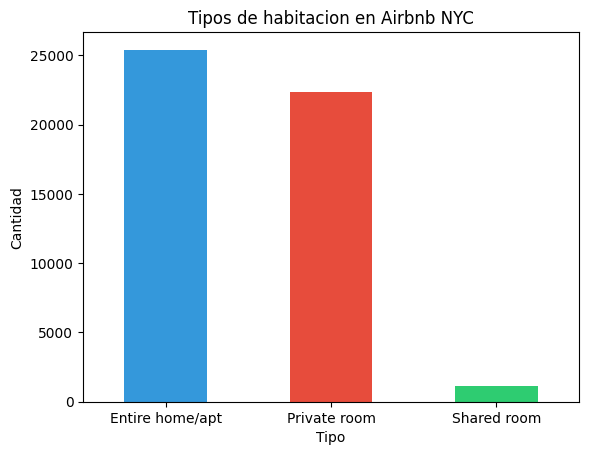

In [48]:
print('Tipos de habitacion:')
print(df['room_type'].value_counts())

df['room_type'].value_counts().plot(kind='bar', color=['#3498db','#e74c3c','#2ecc71'])
plt.title('Tipos de habitacion en Airbnb NYC')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

In [49]:
#Ahora vamos a seleccionar nuestras variables para responder a la pregunta:
# ¿Podemos predecir si un Airbnb en Nueva York es un apartamento entero o no?

columnas = ['price', 'neighbourhood_group', 'latitude', 'longitude', 'minimum_nights','number_of_reviews', 'room_type']
df = df[columnas].copy()
print('Dataset reducido:', df.shape)
df.head()

Dataset reducido: (48895, 7)


,price,neighbourhood_group,latitude,longitude,minimum_nights,number_of_reviews,room_type
0,149,Brooklyn,40.64749,-73.97237,1,9,Private room
1,225,Manhattan,40.75362,-73.98377,1,45,Entire home/apt
2,150,Manhattan,40.80902,-73.94190,3,0,Private room
3,89,Brooklyn,40.68514,-73.95976,1,270,Entire home/apt
4,80,Manhattan,40.79851,-73.94399,10,9,Entire home/apt


In [50]:
#Vemos si hay valores nulos

print('Valores nulos por columna:')
print(df.isnull().sum())
df = df.dropna()
print('Filas despues de eliminar nulos:', len(df))

Valores nulos por columna:
price                  0
neighbourhood_group    0
latitude               0
longitude              0
minimum_nights         0
number_of_reviews      0
room_type              0
dtype: int64
Filas despues de eliminar nulos: 48895


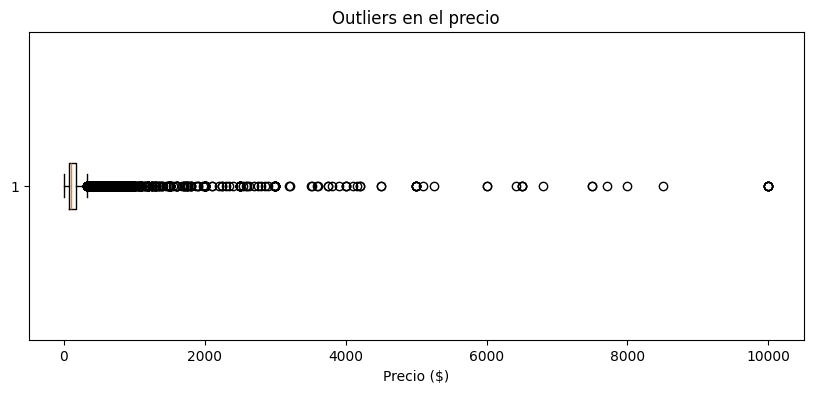

In [51]:
# Para ver los outliers usamos el Boxlot.
# Observamos que hay muchos outliers debido a los precios elevados que hay en NY respecto a la media
plt.figure(figsize=(10,4))
plt.boxplot(df['price'], vert=False)
plt.title('Outliers en el precio')
plt.xlabel('Precio ($)')
plt.show()

In [52]:
# Vamos a eliminar los outlier para que no confunda al modelo y también porque laRegresio LOGISTICA es sensbles 
# a los valores a los valores extremos, no usamos dropna porque es para valores nulos

percentil_99 = df['price'].quantile(0.99)
df = df[df['price'] <= percentil_99]
df = df[df['price'] > 0]
print('Precio máximo después de limpiar:', df['price'].max())
print('Filas restantes:', len(df))


Precio máximo después de limpiar: 799
Filas restantes: 48410


In [53]:
#Creamos el encoder 

encoder = OneHotEncoder(sparse_output=False)

In [54]:
#configurar la columna  neighbourhood_group ya que tiene texto y darle un numero por cada distrito

encoded = encoder.fit_transform(df[['neighbourhood_group']])

In [55]:
#Lo convierto en DataFrame con la columna que hemos modificado para luego unirlo con las otras columnas

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['neighbourhood_group']), index=df.index)

In [ ]:
# Ahora uno las columnas

df = pd.concat([df, encoded_df], axis=1)

In [57]:
# Elimino la columna original que está en formato texto que no me sirve 

df = df.drop(columns=['neighbourhood_group'], errors='ignore')

print('Dataset con encoding:', df.shape)
df.head()

Dataset con encoding: (48410, 11)


,price,latitude,longitude,minimum_nights,number_of_reviews,room_type,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,149,40.64749,-73.97237,1,9,Private room,0.0,1.0,0.0,0.0,0.0
1,225,40.75362,-73.98377,1,45,Entire home/apt,0.0,0.0,1.0,0.0,0.0
2,150,40.80902,-73.94190,3,0,Private room,0.0,0.0,1.0,0.0,0.0
3,89,40.68514,-73.95976,1,270,Entire home/apt,0.0,1.0,0.0,0.0,0.0
4,80,40.79851,-73.94399,10,9,Entire home/apt,0.0,0.0,1.0,0.0,0.0


In [59]:
# Vamos a hacer escalado de las variables: price (0 a 300), latitude (entre 40.4 y 40.09), minimum_nights

scaler = StandardScaler()

columnas_escalar = ['price', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews']

df[columnas_escalar] = scaler.fit_transform(df[columnas_escalar])

print('Escalado aplicado correctamente')
df.head()

Escalado aplicado correctamente


,price,latitude,longitude,minimum_nights,number_of_reviews,room_type,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,0.110088,-1.490656,-0.442676,-0.294658,-0.322433,Private room,0.0,1.0,0.0,0.0,0.0
1,0.842413,0.452406,-0.689616,-0.294658,0.482942,Entire home/apt,0.0,0.0,1.0,0.0,0.0
2,0.119724,1.466687,0.217347,-0.196102,-0.523777,Private room,0.0,0.0,1.0,0.0,0.0
3,-0.468064,-0.801348,-0.169526,-0.294658,5.516539,Entire home/apt,0.0,1.0,0.0,0.0,0.0
4,-0.554786,1.274266,0.172074,0.148844,-0.322433,Entire home/apt,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Convertimos room_type en 1 (apartamento entero) o 0 (no)
df['es_apartamento'] = (df['room_type'] == 'Entire home/apt').astype(int)
df = df.drop(columns=['room_type'])
print(df['es_apartamento'].value_counts())

es_apartamento
1    25022
0    23388
Name: count, dtype: int64


In [61]:
#Definimos X e Y 

X = df.drop(columns=['es_apartamento'])
y = df['es_apartamento']
print('X:', X.shape)
print('Y:', y.shape)

X: (48410, 10)
Y: (48410,)


In [62]:
#Separamos en train y test reservando el 20%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Datos para entrenar:', X_train.shape)
print('Datos para el test: ', X_test.shape)

Datos para entrenar: (38728, 10)
Datos para el test:  (9682, 10)


In [63]:
#Ahora entrenamos al modelo con la Regresion Logistica

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)
print('Modelo entrenado correctamente')

Modelo entrenado correctamente


In [64]:
# Predicción y resultado aqui no usaremos y_test ya que el objetivo es que el modelo use solo lo ue ha aprendido.
#x_test, para intentar adivinar que pasó

y_pred = modelo.predict(X_test)

print(y_pred)

[1 1 0 ... 0 0 1]


In [ ]:
#Otra métrica importante es la Accuracy Score con ellas vamos a tener una respuesta mas directa 
#nos un resultado muy bueno del 81,95% por lo tanto este modelo es factiblees fiable.

precision = accuracy_score(y_test, y_pred)
print(f'Accuracy del modelo: {precision*100:.2f}%')

Accuracy del modelo: 81.95%


In [ ]:
#Finalmente la Matriz de Confusion para confirmar qe lo que hems calculado ha ido bien.
#Vemos que el modelo ha predicho que los verdaderos negativos son 4.023 NO son apartamentos y que 3.911 son aparamentos
#aciertos totales = 4.023 + 3.911 =7.934 --> el modelo acertó en un 82% de los casos
#Es modelo es bueno detectando los que no son apartamento
# Esto significa que el precio, la ubicación, las noches mínimas 
# y el número de reseñas son buenos indicadores para saber si un alojamiento es un apartamento entero o no.
#Los apartamentos enteros tienden a estar en zonas concretas de Nueva York 
# y a tener precios diferentes a las habitaciones privadas o compartidas.

matriz= confusion_matrix(y_test, y_pred)
print(matriz)

[[4023  610]
 [1138 3911]]
